# The factor zoo went retail: did the ETFs deliver? 🏷️
### USMV, MTUM, VLUE, QUAL vs the S&P 500 — thirteen live years, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beat SPY outright?: Busted](https://img.shields.io/badge/Beat_SPY_outright%3F-Busted-8b949e?style=flat-square)

Between 2011 and 2013, BlackRock did something academics had promised for decades: it put the famous **factor premia** — low-volatility, momentum, value, quality — into ordinary ETFs anyone can buy for 0.15%/yr. The pitch was simple: *these patterns beat the market in a hundred years of data; now you can own them with one ticket.*

That was a decade and a half ago. These funds now hold tens of billions of dollars. So — did each one actually **deliver**? We audit the four flagship funds against SPY, since each fund's first day, on total returns, net of their own fees.

> 📓 **Plain-language layer.** Want the Newey-West regressions, bootstraps and placebos? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Dedup note.** The desk already graded the *academic* versions of these claims ([330-low-volatility-anomaly](../../330-low-volatility-anomaly/), [242-quality-minus-junk](../../242-quality-minus-junk/)). This study asks a different question: did the **shipped products** do what the label says? Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from factor_etf_live_test import data, strategy as st

FUNDS = data.FUNDS
HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPE = data.load_tape()
    MRET = data.monthly_total_returns(TAPE[[c for c in TAPE.columns if c != "^IRX"]])
    RF = data.monthly_rf(TAPE["^IRX"])
    SPY = MRET["SPY"].dropna()
    WML = data.sector_momentum_spread(MRET[data.SECTORS].dropna())
    VMG = data.value_spread(MRET)
    QMB = data.quality_spread(MRET)
    SPREADS = {"MTUM": WML, "VLUE": VMG, "QUAL": QMB}

    def fund_frame(tk):
        r = MRET[tk].dropna()
        idx = r.index.intersection(SPY.index).intersection(RF.dropna().index)
        return r.loc[idx], SPY.loc[idx], RF.loc[idx]
else:
    TAPE = MRET = RF = SPY = WML = VMG = QMB = None
    SPREADS = {}
print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-03', 'last_month': '2026-06-30', 'fingerprint': 'fd36c691c5cb', 'funds': {'USMV': {'start': '2011-11', 'n': 176, 'beta': 0.689, 'se': 0.041, 't_b1': -7.52, 'r2': 74.0, 'alpha': 0.69, 't_a': 0.47, 'vr': 0.799, 'vr_lo': 0.741, 'vr_hi': 0.876, 'vol': 11.2, 'spy_vol': 14.0, 'up': 71.9, 'down': 65.9, 'cagr': 11.44, 'spy_cagr': 14.94, 'sh': 0.887, 'spy_sh': 0.959, 'dd': -19.1, 'w': 4.9, 'spy_w': 7.71, 'act': -28.9, 't_act': -1.94}, 'MTUM': {'start': '2013-05', 'n': 158, 'beta': 0.979, 'se': 0.051, 't_b1': -0.4, 'r2': 75.4, 'alpha': 2.65, 't_a': 1.1, 'vr': 1.129, 'vr_lo': 1.002, 'vr_hi': 1.223, 'vol': 16.3, 'spy_vol': 14.4, 'up': 99.9, 'down': 81.8, 'cagr': 16.8, 'spy_cagr': 14.38, 'sh': 0.934, 'spy_sh': 0.887, 'dd': -30.2, 'w': 7.72, 'spy_w': 5.86, 'act': 19.9, 't_act': 0.93}, 'VLUE': {'start': '2013-05', 'n': 158, 'beta': 1.077, 'se': 0.058, 't_b1': 1.34, 'r2': 76.6, 'alpha': -0.96, 't_a': -0.32, 'vr': 1.231, 'vr_lo': 1.073, 'vr_hi': 1.317, 'vol': 17.7, 'spy_vol': 14.4, 'up': 103.3, 'down': 106.9, 'cagr': 13.81, 'spy_cagr': 14.38, 'sh': 0.722, 'spy_sh': 0.887, 'dd': -29.0, 'w': 5.49, 'spy_w': 5.86, 'act': 0.2, 't_act': 0.01}, 'QUAL': {'start': '2013-08', 'n': 155, 'beta': 0.993, 'se': 0.021, 't_b1': -0.36, 'r2': 96.1, 'alpha': -0.23, 't_a': -0.28, 'vr': 1.013, 'vr_lo': 0.985, 'vr_hi': 1.055, 'vol': 14.7, 'spy_vol': 14.5, 'up': 98.2, 'down': 98.7, 'cagr': 13.75, 'spy_cagr': 14.14, 'sh': 0.834, 'spy_sh': 0.867, 'dd': -27.8, 'w': 5.28, 'spy_w': 5.52, 'act': -2.7, 't_act': -0.41}}, 'spy_dd': -23.9, 'style': {'MTUM': {'name': 'sector 12-1 WML', 'load': 0.326, 't': 7.45, 'r2': 81.9, 'pos': 96.2, 'neg': -64.5, 'diff': 160.7, 'welch': 4.59, 'p': 0.0}, 'VLUE': {'name': 'IWD-IWF value spread', 'load': 0.517, 't': 9.99, 'r2': 85.6, 'pos': 131.2, 'neg': -84.5, 'diff': 215.7, 'welch': 6.06, 'p': 0.0}, 'QUAL': {'name': 'SPHQ-SPY quality spread', 'load': 0.384, 't': 8.76, 'r2': 97.4, 'pos': 20.7, 'neg': -26.4, 'diff': 47.1, 'welch': 3.63, 'p': 0.0003}}, 'alpha_lags': {'USMV': (0.45, 0.47, 0.47), 'MTUM': (1.11, 1.1, 1.24), 'VLUE': (-0.36, -0.32, -0.31), 'QUAL': (-0.29, -0.28, -0.27)}, 'proxies': {'WML': (5.5, 0.28), 'VMG': (-4.4, -0.22), 'QMB': (-4.8, -0.42)}, 'syn': {'null': {'beta': 1.019, 't_b1': 1.82, 'load': 0.01, 't_l': 0.56, 'a': -0.56, 't_a': -1.02}, 'planted': {'beta': 0.717, 't_b1': -10.54, 'load': 0.51, 't_l': 27.37, 'a': 2.44, 't_a': 4.43}}}


real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did each fund deliver its promised *exposure*? | **Yes — decisively.** USMV really is ~20% less volatile than SPY (beta 0.69); MTUM really moves with momentum, VLUE with value, QUAL with quality — all at *t*-statistics of 7 to 10. |
| Did any deliver *alpha* (market-beating risk-adjusted return)? | **No.** Alphas sit between -1.0% and +2.6%/yr — all statistically zero. |
| Did any simply beat SPY? | **No — busted.** Three of four *lagged* SPY; MTUM finished ahead (+2.4 pp/yr) but well within noise. |
| So what did buyers actually get? | A **risk profile**, faithfully delivered — not an edge. USMV holders got smaller crashes (down-capture 66%) and 3.5 pp/yr less return. |

## Four races against the index they were sold to beat

Growth of $1, each fund vs SPY over the *same* window (every fund's own life). Total returns, net of fees:

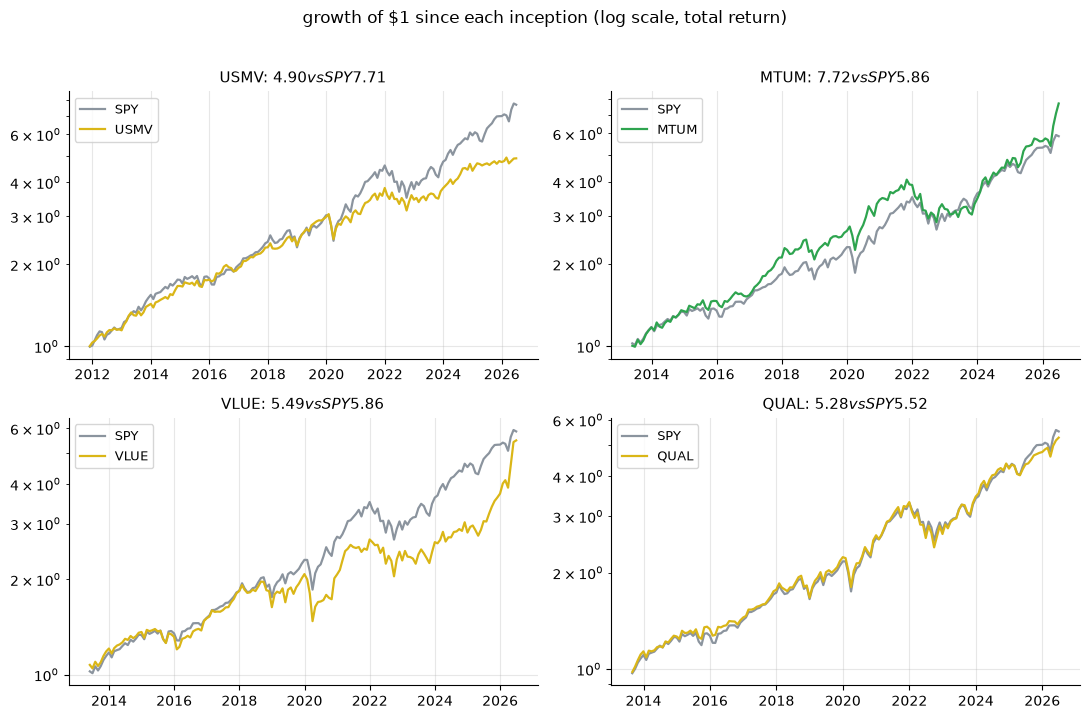

USMV: CAGR 11.44% vs SPY 14.94%  (gap -3.50 pp/yr)
MTUM: CAGR 16.80% vs SPY 14.38%  (gap +2.42 pp/yr)
VLUE: CAGR 13.81% vs SPY 14.38%  (gap -0.57 pp/yr)
QUAL: CAGR 13.75% vs SPY 14.14%  (gap -0.39 pp/yr)


In [2]:
if HAVE_REAL:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
    for ax, tk in zip(axes.ravel(), FUNDS):
        r, sp, f = fund_frame(tk)
        ax.plot((1+sp).cumprod(), color=GREY, lw=1.6, label='SPY')
        ax.plot((1+r).cumprod(), color=GREEN if tk=='MTUM' else AMBER, lw=1.6, label=tk)
        ax.set_yscale('log'); ax.legend(fontsize=9)
        ax.set_title(f"{tk}: ${R['funds'][tk]['w']:.2f} vs SPY ${R['funds'][tk]['spy_w']:.2f}", fontsize=11)
    fig.suptitle('growth of $1 since each inception (log scale, total return)', y=1.02)
    plt.tight_layout(); plt.show()
    for tk in FUNDS:
        d = R['funds'][tk]
        print(f"{tk}: CAGR {d['cagr']:.2f}% vs SPY {d['spy_cagr']:.2f}%  (gap {d['cagr']-d['spy_cagr']:+.2f} pp/yr)")
else:
    print('cache missing — see docs/results.md for the frozen numbers')


Only **MTUM** ends ahead of SPY — and the quants will show even that gap is statistical noise. **USMV**, the largest factor ETF in the world, trails by **3.5 percentage points a year**. Is that a scandal? No — and that's the whole point of this study. Keep reading.

## Half one of the promise: the exposure — delivered, beautifully

Each fund's label makes a checkable claim. USMV's is the easiest: *you will be less volatile than the market.* Watch its rolling volatility against SPY's:

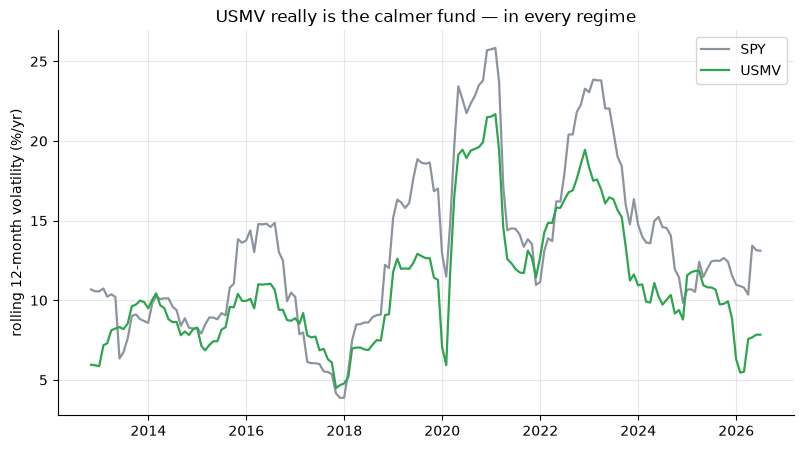

full-window vol: USMV 11.2% vs SPY 14.0%  (ratio 0.80, CI [0.74, 0.88])
beta 0.689; in SPY's down months USMV only falls 66% as far


In [3]:
if HAVE_REAL:
    r, sp, f = fund_frame('USMV')
    fig, ax = plt.subplots()
    ax.plot(sp.rolling(12).std()*np.sqrt(12)*100, color=GREY, lw=1.6, label='SPY')
    ax.plot(r.rolling(12).std()*np.sqrt(12)*100, color=GREEN, lw=1.6, label='USMV')
    ax.set_ylabel('rolling 12-month volatility (%/yr)')
    ax.set_title('USMV really is the calmer fund — in every regime')
    ax.legend(); plt.show()
    d = R['funds']['USMV']
    print(f"full-window vol: USMV {d['vol']:.1f}% vs SPY {d['spy_vol']:.1f}%  "
          f"(ratio {d['vr']:.2f}, CI [{d['vr_lo']:.2f}, {d['vr_hi']:.2f}])")
    print(f"beta {d['beta']:.3f}; in SPY's down months USMV only falls {d['down']:.0f}% as far")


USMV runs at **~80% of SPY's volatility** (a 20% reduction — the low end of the promised 20–30%), catches only **66%** of the market's down months, and its worst peak-to-trough fall was **-19%** vs SPY's -24%. The label is accurate.

The other three labels are checkable too: in months when the *momentum* style won (winners kept winning), MTUM should beat SPY; when *value* won, VLUE should; when *quality* won, QUAL should. Do they?

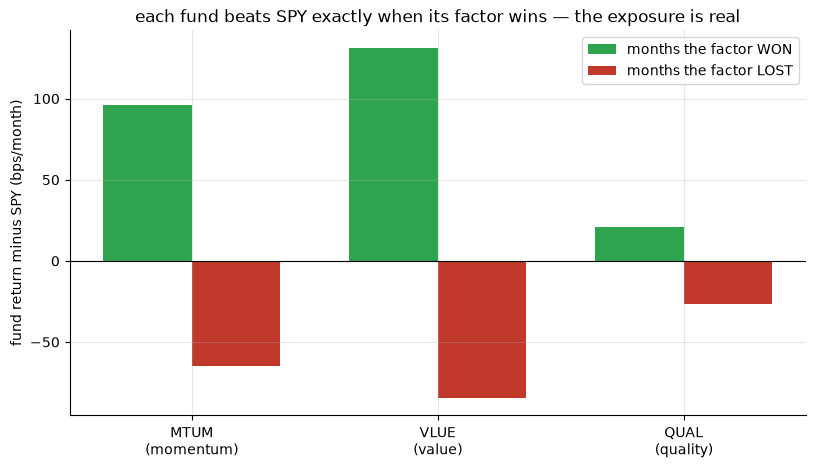

MTUM: +96 bps/mo when its factor won, -64 when it lost (gap +161 bps, t = 4.6)
VLUE: +131 bps/mo when its factor won, -84 when it lost (gap +216 bps, t = 6.1)
QUAL: +21 bps/mo when its factor won, -26 when it lost (gap +47 bps, t = 3.6)


In [4]:
sty = R['style']
fig, ax = plt.subplots()
x = np.arange(3); w = 0.36
pos = [sty[t]['pos'] for t in ('MTUM','VLUE','QUAL')]
neg = [sty[t]['neg'] for t in ('MTUM','VLUE','QUAL')]
ax.bar(x-w/2, pos, w, color=GREEN, label='months the factor WON')
ax.bar(x+w/2, neg, w, color=RED, label='months the factor LOST')
ax.set_xticks(x); ax.set_xticklabels(['MTUM\n(momentum)', 'VLUE\n(value)', 'QUAL\n(quality)'])
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('fund return minus SPY (bps/month)')
ax.set_title('each fund beats SPY exactly when its factor wins — the exposure is real')
ax.legend(); plt.show()
for t in ('MTUM','VLUE','QUAL'):
    s = sty[t]
    print(f"{t}: {s['pos']:+.0f} bps/mo when its factor won, {s['neg']:+.0f} when it lost "
          f"(gap {s['diff']:+.0f} bps, t = {s['welch']:.1f})")


Textbook behaviour. Each fund out-runs SPY precisely in its factor's good months and lags in the bad ones, at *t*-statistics between 3.6 and 6.1 (regression loadings: 7 to 10). **The wrappers work.** Whatever you think of factor investing, the engineering delivered exactly what it printed on the tin.

> 🔬 **For the quants:** the loadings come from a two-factor Newey-West regression of fund excess return on [market, realized style spread]; the splits carry 10,000-draw permutation placebos (*p* ≤ 0.0003). Notebook 02 has the full grid.

## Half two of the promise: the alpha — missing

The academic papers didn't just say these factors *exist* — they said they **pay**: higher risk-adjusted returns than the market. That's the CAPM alpha. Here it is for the four live funds, with the statistical bar drawn where the desk always draws it:

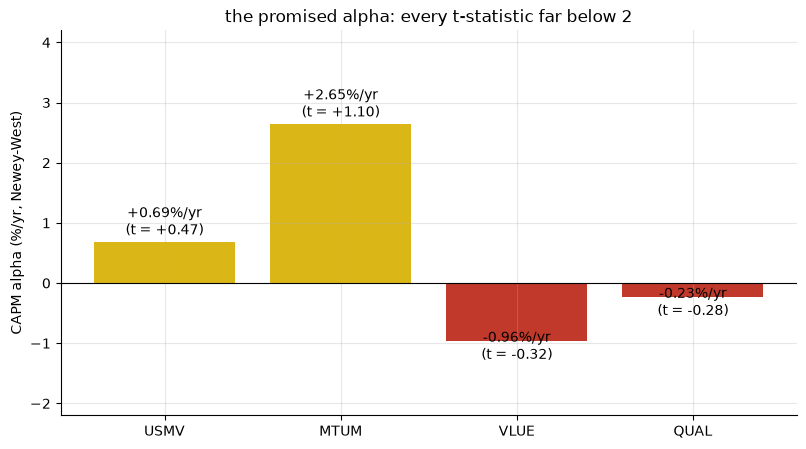

the desk bar: REAL needs a robust t >= 2 on the real tape — none comes close


In [5]:
F = R['funds']
fig, ax = plt.subplots()
names = list(F)
alphas = [F[t]['alpha'] for t in names]
tstats = [F[t]['t_a'] for t in names]
cols = [AMBER if a > 0 else RED for a in alphas]
bars = ax.bar(names, alphas, color=cols)
for b, a, t in zip(bars, alphas, tstats):
    ax.text(b.get_x()+b.get_width()/2, a + (0.12 if a>=0 else -0.3),
            f'{a:+.2f}%/yr\n(t = {t:+.2f})', ha='center', fontsize=10)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('CAPM alpha (%/yr, Newey-West)')
ax.set_ylim(-2.2, 4.2)
ax.set_title('the promised alpha: every t-statistic far below 2')
plt.show()
print('the desk bar: REAL needs a robust t >= 2 on the real tape — none comes close')


Nothing clears the bar, or comes near it. MTUM's +2.65%/yr *looks* like something until you see *t* = 1.10 — thirteen years of monthly data cannot tell it from luck. And here's the deeper reason: the **factors themselves didn't pay** over this window. Our momentum spread earned ~5 bps/month, the value spread ~−4, the quality spread ~−5 — all statistically zero. The funds faithfully tracked styles that went nowhere.

That's the honest reading of the great smart-beta experiment: the products worked; the *premia* — measured after the papers were published, after the launch wave, after everyone piled in — did not show up.

## The verdict, in plain words

- **Exposure: delivered.** Every label is accurate, at overwhelming statistical strength. If you want 20% less volatility (USMV) or a genuine momentum tilt (MTUM), the wrapper gives you exactly that for 0.15%/yr.
- **Alpha: not delivered.** All four CAPM alphas are statistically zero; the style spreads themselves paid nothing over the live window.
- **Beating SPY: busted.** None did at significance — three of four lagged outright. USMV's −3.5 pp/yr is not a failure of the fund; it's what beta 0.69 costs in a fifteen-year bull market. Buyers got the smoother ride they paid for — many just thought they were buying outperformance too.
- **Caveat:** these are the four flagship *survivors* of the launch wave — the average factor-ETF experience is worse.
**Signal: Real (exposure). Tradability: Fragile. Beat SPY outright: Busted.**

> 📓 Full statistics, robustness grids and the honest fine print: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** · frozen numbers: [`docs/results.md`](../docs/results.md) (fingerprint `fd36c691c5cb`).

*Research & education, not investment advice.*